# LendingClub Final Research Report

This notebook is a final narrative report for dataset-level research review. It intentionally keeps logic in `credit_risk_fs.reporting.notebook_report` and uses the notebook only for loading, display, and interpretation.


In [1]:
from pathlib import Path
import sys

if not Path('_legacy_shim.py').exists():
    candidate_root = Path.cwd().resolve().parents[1]
    if str(candidate_root) not in sys.path:
        sys.path.insert(0, str(candidate_root))

from IPython.display import Markdown, display

from credit_risk_fs.reporting.notebook_report import (
    load_best_runs,
    load_dataset_report_inputs,
    load_final_comparison,
    load_run_artifacts,
    plot_bad_rate_by_time,
    plot_dev_oot_split_diagnostics,
    plot_drift_vs_performance,
    plot_metric_leaderboard,
    plot_observation_count_by_time,
    plot_runtime_tradeoff,
    plot_semantic_coverage,
    plot_stability_vs_performance,
    summarize_clip_validation_placeholder,
    summarize_dataset_findings,
    summarize_split_rationale,
)

dataset_name = 'lendingclub'
inputs = load_dataset_report_inputs(dataset_name)
final_df = load_final_comparison(dataset_name)
findings = summarize_dataset_findings(dataset_name)
clip_placeholder = summarize_clip_validation_placeholder(dataset_name)


## Research Question and Dataset Role

The research question is whether LLM-based metadata screening is useful as a first-stage feature-selection helper for credit scoring. LendingClub is the external validation dataset in the repository. LR and CatBoost are evaluation vehicles rather than the core research contribution. Calibration, stacking, deployment logic, and any CLIP-style method implementation are out of scope in this report.


## Dataset Snapshot

The snapshot below is intended to anchor the rest of the report around the actual split, feature budget, and completed-run footprint rather than around isolated metrics.


In [2]:
if inputs['warnings']:
    display(Markdown('**Warnings and incomplete sections**'))
    for warning in inputs['warnings']:
        display(Markdown(f'- {warning}'))

display(inputs['snapshot'])


**Warnings and incomplete sections**

- No separate encoded-feature-count artifact exists; the snapshot reports engineered candidate features from experiment summaries and source-table width from the processed application table.

,dataset_name,dataset_role,DEV_rows,OOT_rows,DEV_bad_rate,OOT_bad_rate,time_column,DEV_window,OOT_window,engineered_candidate_features,encoded_or_modeling_features_if_available,LR_feature_budget,CatBoost_feature_budget,completed_runs,failed_runs
0,LendingClub,external validation,598649,293105,0.1954,0.2329,recent_decision,"[-1795, -1065)","[-1065, -730]",300.0,97.0,20.0,40.0,16,0


## DEV/OOT Split Rationale

This section is mandatory because the research claim depends on realistic future-period validation rather than on random holdout performance.


The split is time-based rather than random. DEV is the older window used for cross-validation, feature selection, and model fitting, while OOT is the newer holdout used only for final evaluation. The window choice is justified by observation counts and target-rate behavior across time, with the goal of keeping both periods large enough for comparison without leaking future information into selector or model tuning. OOT bad rate is reported only to justify the validation setup; it is not used to tune feature selection or hyperparameters. For LendingClub, the configured relative window uses DEV from -1795 inclusive to -1065 exclusive and OOT from -1065 inclusive to -730 inclusive on `recent_decision`, which is derived from issue date to simulate future-loan validation. On the processed LendingClub application table, the DEV window corresponds approximately to issue dates 2017-05-01 through 2018-04-01, and OOT corresponds to 2018-05-01 through 2018-12-01. This produces 598,649 DEV rows and 293,105 OOT rows, with bad rates of 0.1954 and 0.2329; the difference is 0.0375.

,dataset,dataset_display_name,time_column,DEV_start,DEV_end,OOT_start,OOT_end,DEV_window,OOT_window,DEV_rows,...,OOT_bad_rate,bad_rate_difference,OOT_DEV_row_ratio,dropped_older_rows,dropped_missing_time_rows,source_row_count,DEV_issue_date_start,DEV_issue_date_end,OOT_issue_date_start,OOT_issue_date_end
0,lendingclub,LendingClub,recent_decision,-1795,-1065,-1065,-730,"[-1795, -1065)","[-1065, -730]",598649,...,0.2329,0.0375,0.4896,230706,0,1348099,2017-05-01,2018-04-01,2018-05-01,2018-12-01


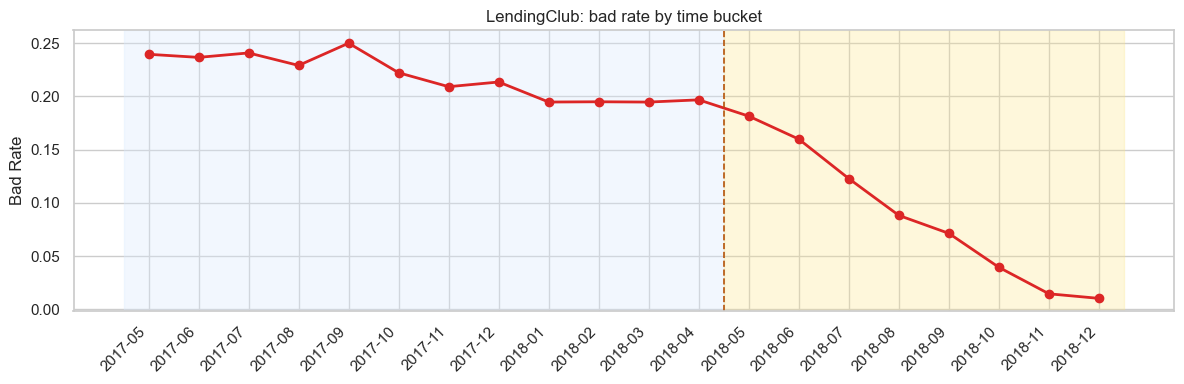

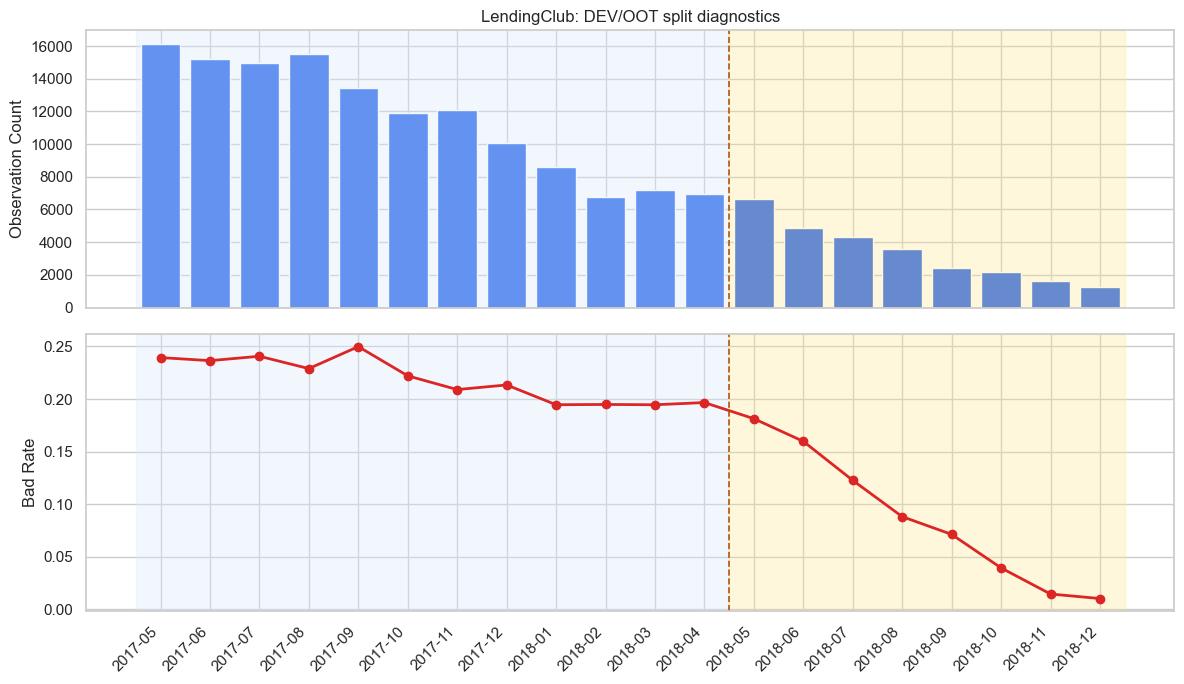

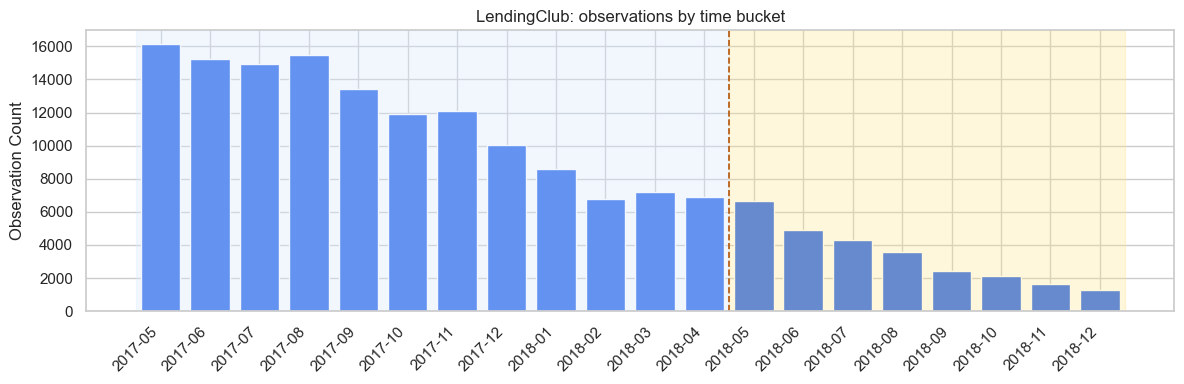

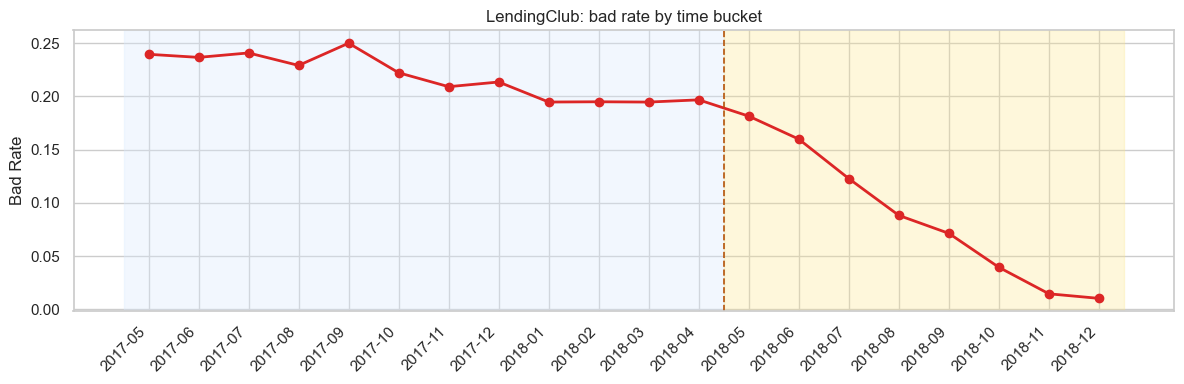

In [3]:
display(Markdown(summarize_split_rationale(dataset_name)))
display(inputs['split_summary'])
plot_dev_oot_split_diagnostics(dataset_name)
plot_observation_count_by_time(dataset_name)
plot_bad_rate_by_time(dataset_name)


## Experiment Matrix Overview

The matrix should be read as a controlled comparison across statistical baselines, LLM-only screening, and hybrid first-stage screening rather than as a search for a single universally dominant selector.


In [4]:
display(inputs['matrix_overview'])
display(Markdown(findings['experiment_matrix_markdown']))


,dataset,models,selectors,feature_budgets,completed_run_count,failed_run_count
0,lendingclub,"catboost, lr","mrmr, boruta, pca, domain_rule_baseline, llm, ...","20, 40",16,0


The matrix compares statistical baselines, pure LLM screening, and LLM-then-statistical hybrids under the same DEV/OOT protocol. The target comparison is therefore about first-stage screening utility, not about replacing the downstream LR or CatBoost evaluation vehicles.

## Topline Performance Comparison

This section stays concise on purpose. The point is to identify where the strongest OOT results sit and whether the gap over the best baseline is meaningful or only marginal.


,model,selector,experiment_type,oot_auc,oot_gini,oot_ks,lift_at_10,selected_feature_count,runtime_seconds,model_score_psi
0,lr,llm,llm,0.6982,0.3965,0.2830,2.1306,20.0,353.2234,0.0058
1,lr,llm_then_mrmr,hybrid,0.6940,0.3881,0.2780,2.1082,20.0,273.5664,0.0051
2,lr,pca,statistical,0.6918,0.3835,0.2770,2.0954,20.0,81.8562,0.0139
3,lr,mrmr,statistical,0.6908,0.3816,0.2750,2.0998,20.0,428.6104,0.0042
4,lr,stable_core_llm_fill,hybrid,0.6907,0.3815,0.2735,2.0976,20.0,1705.7226,0.0040
5,lr,llm_then_boruta,hybrid,0.6534,0.3069,0.2219,1.7696,20.0,2110.3166,0.0078
6,lr,boruta,statistical,0.6350,0.2700,0.1977,1.6931,20.0,4143.0061,0.0079
7,lr,domain_rule_baseline,statistical,0.6199,0.2399,0.1734,1.6130,20.0,58.3984,0.0242
8,catboost,llm,llm,0.7165,0.4329,0.3103,2.2538,40.0,3624.1757,0.0055
9,catboost,llm_then_mrmr,hybrid,0.7071,0.4143,0.2973,2.2009,40.0,3581.0058,0.0071


LendingClub acts as external validation, and the OOT leaderboard is tighter than on Home Credit. For LR, `llm` is best on OOT AUC (0.6982); for CatBoost, `llm` is best at 0.7165. The strongest non-LLM baseline is `mrmr` at 0.7060. The headline is not universal dominance: the best LLM-family methods sit near the top, but the margins over mRMR are modest. Paired-fold CV deltas versus the mRMR baseline were positive (mean AUC delta 0.0007, 95% CI 0.0001 to 0.0012). Paired-fold CV deltas versus the mRMR baseline were inconclusive (mean AUC delta 0.0003, 95% CI -0.0115 to 0.0121).

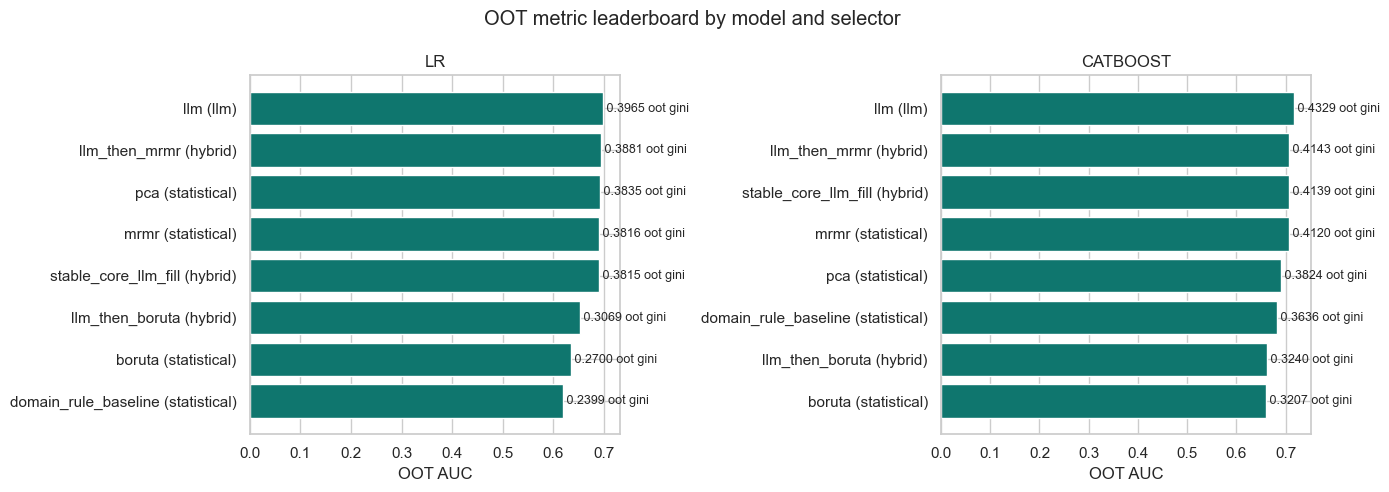

In [5]:
leaderboard_columns = [
    'model',
    'selector',
    'experiment_type',
    'oot_auc',
    'oot_gini',
    'oot_ks',
    'lift_at_10',
    'selected_feature_count',
    'runtime_seconds',
    'model_score_psi',
]
display(final_df[leaderboard_columns])
plot_metric_leaderboard(final_df)
display(Markdown(findings['topline_markdown']))


## Stability Review

Exact feature-set repeatability and semantic stability should be treated separately. Strong OOT performance is useful only if the selected set is not erratic across folds.


,dataset_name,model,selector,experiment_type,nogueira_stability,kuncheva_stability,mean_pairwise_jaccard,semantic_group_jaccard,stable_feature_count_80,stable_feature_ratio_80,stable_semantic_group_count_80,semantic_group_stable_ratio_80,spearman_rank_stability_mean,kendall_rank_stability_mean,rbo_rank_stability_mean
0,lendingclub,catboost,pca,statistical,1.0000,1.0000,1.0000,1.0000,40.0,1.000,1.0,1.00,1.0000,1.0000,NaN
1,lendingclub,catboost,domain_rule_baseline,statistical,1.0000,1.0000,1.0000,1.0000,40.0,1.000,5.0,1.00,1.0000,1.0000,NaN
2,lendingclub,catboost,llm_then_mrmr,hybrid,0.8096,0.8096,0.7197,0.8500,32.0,0.800,3.0,1.00,0.5590,0.4256,NaN
3,lendingclub,catboost,mrmr,statistical,0.7981,0.7981,0.7081,0.9000,34.0,0.850,3.0,1.00,0.7425,0.5607,NaN
4,lendingclub,catboost,stable_core_llm_fill,hybrid,0.7779,0.7779,0.6834,1.0000,33.0,0.825,3.0,1.00,0.5590,0.4256,NaN
5,lendingclub,catboost,llm_then_boruta,hybrid,0.7288,0.7288,0.6421,0.8500,31.0,0.775,3.0,1.00,0.5590,0.4256,NaN
6,lendingclub,catboost,llm,llm,0.7288,0.7288,0.6230,0.8000,28.0,0.700,2.0,1.00,0.5590,0.4256,NaN
7,lendingclub,catboost,boruta,statistical,0.7029,0.7029,0.6179,0.7150,28.0,0.700,3.0,0.75,0.5695,0.5339,NaN
8,lendingclub,lr,pca,statistical,1.0000,1.0000,1.0000,1.0000,20.0,1.000,1.0,1.00,1.0000,1.0000,NaN
9,lendingclub,lr,domain_rule_baseline,statistical,1.0000,1.0000,1.0000,1.0000,20.0,1.000,2.0,1.00,1.0000,1.0000,NaN


The stability picture is better for the stronger hybrids than for the pure LLM selector. `domain_rule_baseline` on `catboost` has the highest saved Nogueira stability at 1.0000. Again, perfect-repeatability selectors such as PCA should not be overread: semantic concentration and weak robustness matter more than exact repeatability alone.

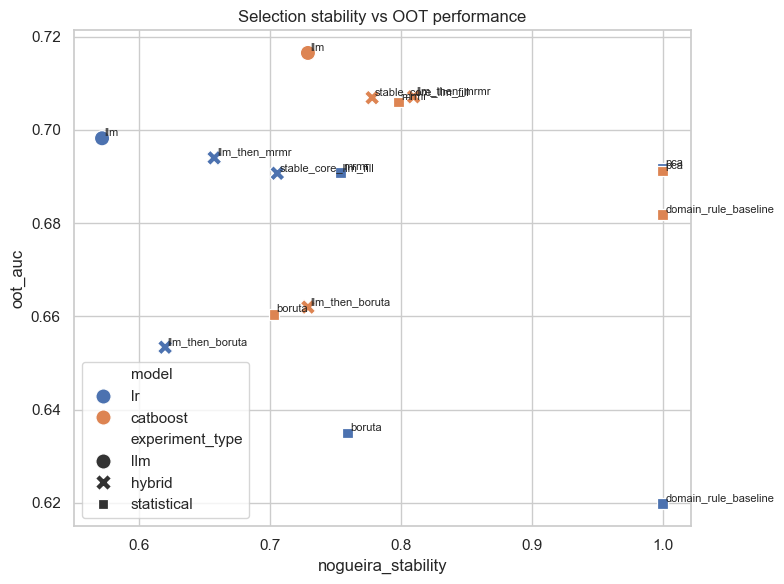

In [6]:
display(inputs['stability_table'])
plot_stability_vs_performance(inputs['stability_table'], final_df)
display(Markdown(findings['stability_markdown']))


## Drift and Robustness Review

OOT PSI is evaluation-only in this report. It is not a tuning signal and should be read as a robustness check on the selected feature set and resulting model scores.


,model,selector,experiment_type,selected_feature_psi_mean,selected_feature_psi_max,model_score_psi
0,catboost,llm,llm,0.0027,0.0357,0.0055
1,catboost,boruta,statistical,0.0039,0.0344,0.0038
2,catboost,llm_then_boruta,hybrid,0.0044,0.0344,0.0029
3,catboost,mrmr,statistical,0.0060,0.0331,0.0073
4,catboost,llm_then_mrmr,hybrid,0.0061,0.0331,0.0071
5,catboost,stable_core_llm_fill,hybrid,0.0063,0.0331,0.0074
6,catboost,domain_rule_baseline,statistical,0.0098,1.2304,0.0012
7,catboost,pca,statistical,1.0802,9.7747,0.0279
8,lr,domain_rule_baseline,statistical,0.0012,0.0193,0.0242
9,lr,llm,llm,0.0021,0.0357,0.0058


Drift on LendingClub is generally low for the best methods, which is encouraging for the external-validation claim. The best low-drift run in the drift table is `domain_rule_baseline` on `lr` with mean feature PSI 0.0012. PCA is the obvious exception and should be flagged explicitly because its feature PSI is much higher than the rest of the table.

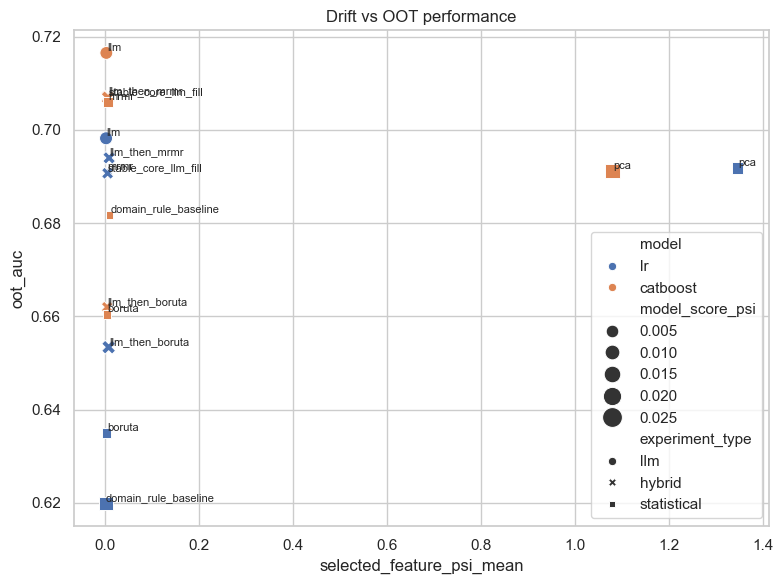

In [7]:
drift_columns = [
    'model',
    'selector',
    'experiment_type',
    'selected_feature_psi_mean',
    'selected_feature_psi_max',
    'model_score_psi',
]
display(inputs['drift_table'][drift_columns])
plot_drift_vs_performance(inputs['drift_table'], final_df)
display(Markdown(findings['drift_markdown']))


## Semantic Coverage Review

The semantic-coverage section is meant to check whether LLM-based screening preserves a broader business-facing view of credit-risk evidence or simply re-creates narrow statistical patterns.


,model,selector,experiment_type,semantic_group_count,dominant_group_ratio,dominant_group
0,catboost,boruta,statistical,5,0.800,other
1,catboost,domain_rule_baseline,statistical,5,0.400,income_capacity
2,catboost,llm,llm,2,0.850,other
3,catboost,llm_then_boruta,hybrid,3,0.900,other
4,catboost,llm_then_mrmr,hybrid,4,0.875,other
5,catboost,mrmr,statistical,3,0.900,other
6,catboost,pca,statistical,1,1.000,other
7,catboost,stable_core_llm_fill,hybrid,3,0.850,other
8,lr,boruta,statistical,2,0.850,other
9,lr,domain_rule_baseline,statistical,2,0.700,delinquency_behavior


Semantic diversity is narrower on LendingClub than on Home Credit because many selected sets collapse into broad 'other' or amount-related groups. That means a good LendingClub result should not be interpreted as proof of richer semantic coverage. The safer reading is that some LLM-family methods remain performance-competitive under a leakage-audited external dataset, even when semantic separation is less expressive.

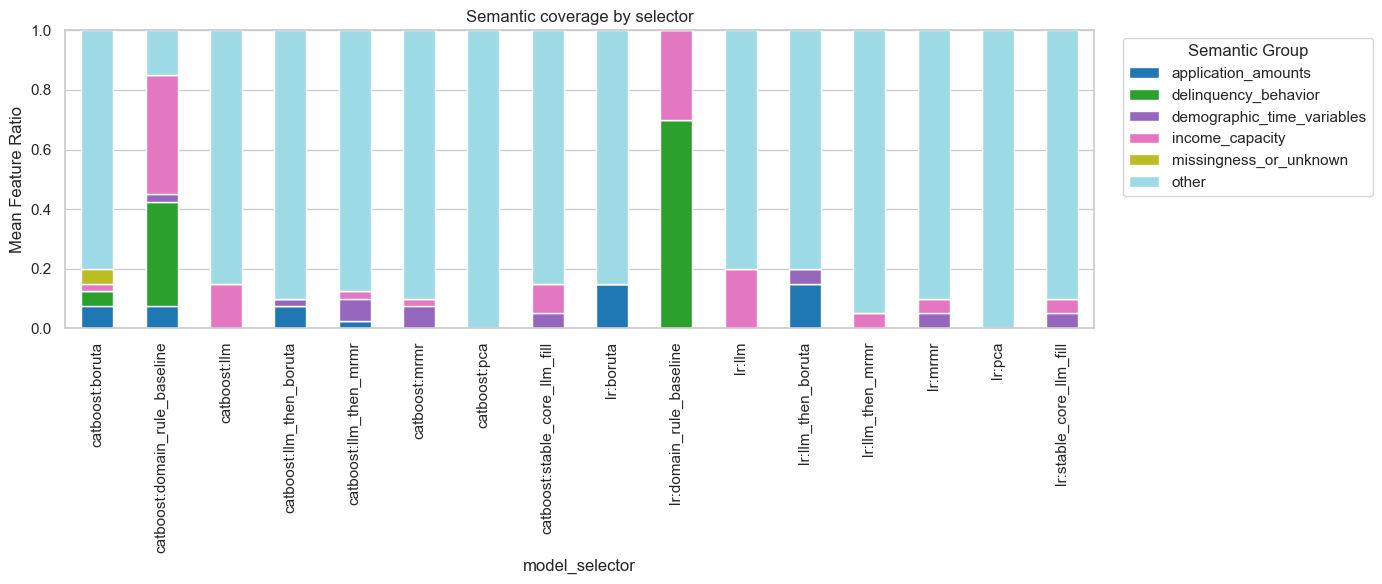

In [8]:
display(inputs['semantic_summary'])
plot_semantic_coverage(inputs['semantic_coverage_table'])
display(Markdown(findings['semantic_markdown']))


## Efficiency Tradeoff

A useful first-stage screener should be judged on runtime, selected-feature compactness, and incremental performance together, not on headline AUC alone.


,model,selector,oot_auc,oot_gini,runtime_seconds,selected_feature_count,feature_reduction_ratio,oot_auc_per_feature
0,lr,llm,0.6982,0.3965,353.2234,20.0,0.9333,0.0349
1,lr,llm_then_mrmr,0.6940,0.3881,273.5664,20.0,0.9333,0.0347
2,lr,pca,0.6918,0.3835,81.8562,20.0,0.9333,0.0346
3,lr,mrmr,0.6908,0.3816,428.6104,20.0,0.9333,0.0345
4,lr,stable_core_llm_fill,0.6907,0.3815,1705.7226,20.0,0.9333,0.0345
5,lr,llm_then_boruta,0.6534,0.3069,2110.3166,20.0,0.9333,0.0327
6,lr,boruta,0.6350,0.2700,4143.0061,20.0,0.9333,0.0317
7,lr,domain_rule_baseline,0.6199,0.2399,58.3984,20.0,0.9333,0.0310
8,catboost,llm,0.7165,0.4329,3624.1757,40.0,0.8667,0.0179
9,catboost,llm_then_mrmr,0.7071,0.4143,3581.0058,40.0,0.8667,0.0177


,run_id,model,selector,llm_calls_actually_made,llm_cache_hits,llm_total_tokens
0,catboost_hybrid_llm_then_boruta_263dc623a138,catboost,llm_then_boruta,0,6,0
1,catboost_hybrid_llm_then_mrmr_429b32e00b37,catboost,llm_then_mrmr,0,6,0
2,catboost_hybrid_stable_core_llm_fill_2d74dcada6cc,catboost,stable_core_llm_fill,0,6,0
3,catboost_llm_llm_fe14a4902388,catboost,llm,0,6,0
4,catboost_statistical_boruta_c2867a0c9909,catboost,boruta,0,0,0
5,catboost_statistical_domain_rule_baseline_6038...,catboost,domain_rule_baseline,0,0,0
6,catboost_statistical_mrmr_e9152da1cab6,catboost,mrmr,0,0,0
7,catboost_statistical_pca_0952e619b24c,catboost,pca,0,0,0
8,lr_hybrid_llm_then_boruta_3ade576dac90,lr,llm_then_boruta,0,6,0
9,lr_hybrid_llm_then_mrmr_ede4e8b044ab,lr,llm_then_mrmr,0,6,0


Efficiency is a more serious tradeoff on LendingClub. Boruta is expensive and weak, while the best LLM-family CatBoost runs are competitive but substantially slower than the best LR runs. The cache behavior still helps: the saved artifacts record 42 cache hits and 66020 total tokens, which indicates that shared ranking and reuse reduce repeated LLM cost.

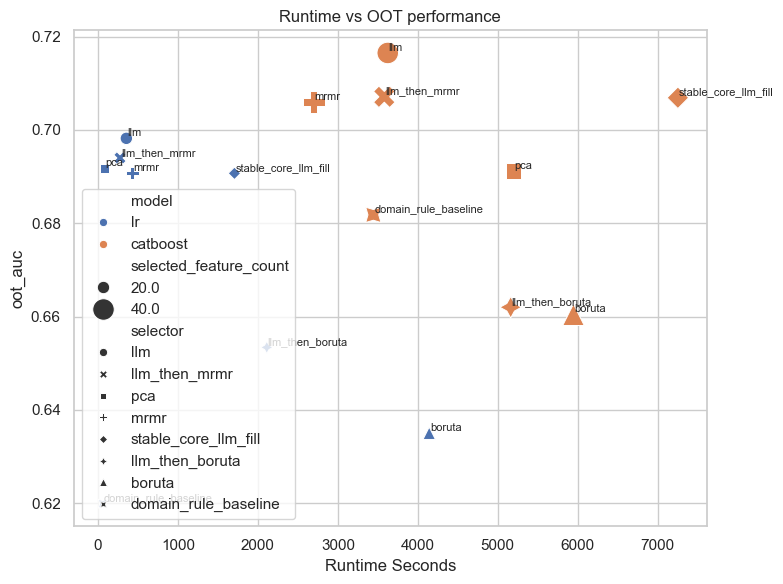

In [9]:
efficiency_columns = [
    'model',
    'selector',
    'oot_auc',
    'oot_gini',
    'runtime_seconds',
    'selected_feature_count',
    'feature_reduction_ratio',
    'oot_auc_per_feature',
]
llm_summary_columns = [
    'run_id',
    'model',
    'selector',
    'llm_calls_actually_made',
    'llm_cache_hits',
    'llm_total_tokens',
]
display(final_df[efficiency_columns])
display(inputs['llm_call_summary'][llm_summary_columns])
plot_runtime_tradeoff(final_df)
display(Markdown(findings['efficiency_markdown']))


## Best Runs Deep Dive

Only a few runs are surfaced here. The goal is to review representative high-value cases rather than dump full feature lists.


In [10]:
best_runs = load_best_runs(dataset_name)
display(best_runs)

for run_id in best_runs['run_id']:
    artifacts = load_run_artifacts(dataset_name, run_id)
    display(Markdown(f'### {run_id}'))
    if not artifacts['summary_table'].empty:
        summary_columns = [
            'model_name',
            'selector_name',
            'cv_auc_mean',
            'cv_auc_std',
            'oot_auc',
            'oot_gini',
            'oot_ks',
            'runtime_seconds',
        ]
        display(artifacts['summary_table'][summary_columns])
    display(artifacts['semantic_group_summary'].head(5))
    display(artifacts['selected_features'][['feature_name', 'semantic_group', 'rank']].head(10))
    display(artifacts['cv_results'][['fold', 'auc', 'gini', 'ks', 'selected_features']].head(5))
    display(artifacts['oot_results'])


,analysis_label,run_id,model,selector,experiment_type,OOT_AUC,OOT_Gini,OOT_KS,CV_AUC_mean,CV_AUC_std,selected_feature_count,top_features,top_semantic_groups,fold_behavior,why_it_matters
0,best LR run,lr_llm_llm_94542581466b,lr,llm,llm,0.6982,0.3965,0.2830,0.7121,0.0230,20.0,"fico_mean, loan_to_income, dti, term, home_own...","other (16), income_capacity (4)",CV AUC 0.7121 +/- 0.0230,highest OOT leaderboard entry for this slice
1,best CatBoost run,catboost_llm_llm_fe14a4902388,catboost,llm,llm,0.7165,0.4329,0.3103,0.7247,0.0227,40.0,"fico_mean, loan_to_income, dti, term, home_own...","other (34), income_capacity (6)",CV AUC 0.7247 +/- 0.0227,highest OOT leaderboard entry for this slice
2,strongest non-LLM baseline,catboost_statistical_mrmr_e9152da1cab6,catboost,mrmr,statistical,0.7060,0.4120,0.2953,0.7244,0.0102,40.0,"term_36 months, acc_open_past_24mths_share, dt...","other (36), demographic_time_variables (3), in...",CV AUC 0.7244 +/- 0.0102,reference baseline for non-LLM comparison


### lr_llm_llm_94542581466b

,model_name,selector_name,cv_auc_mean,cv_auc_std,oot_auc,oot_gini,oot_ks,runtime_seconds
0,lr,llm,0.7121,0.023,0.6982,0.3965,0.283,353.2234


,semantic_group,feature_count,feature_ratio
1,other,16,0.8
0,income_capacity,4,0.2


,feature_name,semantic_group,rank
0,fico_mean,other,1
1,loan_to_income,income_capacity,2
2,dti,other,3
3,term,other,4
4,home_ownership,other,5
5,addr_state,other,6
6,num_tl_op_past_12m,other,7
7,mths_since_recent_inq,other,8
8,total_bal_ex_mort_to_income,income_capacity,9
9,tot_hi_cred_lim_to_income,income_capacity,10


...

,model_name,selector_name,cv_auc_mean,cv_auc_std,oot_auc,oot_gini,oot_ks,runtime_seconds
0,catboost,mrmr,0.7244,0.0102,0.706,0.412,0.2953,2699.7742


,semantic_group,feature_count,feature_ratio
2,other,36,0.900
0,demographic_time_variables,3,0.075
1,income_capacity,1,0.025


,feature_name,semantic_group,rank
0,term_36 months,other,1
1,acc_open_past_24mths_share,other,2
2,dti,other,3
3,fico_range_high,other,4
4,term_home_ownership_60 months__RENT,other,5
5,term_60 months,other,6
6,term_months,other,7
7,fico_mean,other,8
8,loan_to_income,income_capacity,9
9,tot_cur_bal_per_open_acc,other,10


,fold,auc,gini,ks,selected_features
0,1,0.7114,0.4228,0.3079,40.0
1,2,0.7168,0.4336,0.3151,40.0
2,3,0.7256,0.4513,0.3280,40.0
3,4,0.7350,0.4701,0.3423,40.0
4,5,0.7331,0.4662,0.3379,40.0


,gini,auc,ks,ks_threshold,decision_threshold,tn,fp,fn,tp,precision,...,selected_feature_psi_mean,selected_feature_psi_max,selected_feature_psi_median,selected_feature_psi_high_drift_ratio,selected_feature_psi_moderate_or_high_drift_ratio,model_score_psi,lift_at_10,bad_rate_capture_at_10,lift_at_20,bad_rate_capture_at_20
0,0.412,0.706,0.2953,0.4547,0.4905,159663,65190,28778,39474,0.3771,...,0.006,0.0331,0.0011,0.0,0.0,0.0073,2.1956,0.2196,1.8973,0.3795


## Failure Cases and Surprises

This section is intentionally compact. It is here to record weak selectors, ambiguous wins, and dataset-specific caveats that should survive into the written research discussion.


In [11]:
failure_rows = final_df[final_df['selector'].isin(['boruta', 'pca', 'domain_rule_baseline', 'llm', 'stable_core_llm_fill', 'mrmr'])]
display(failure_rows[['model', 'selector', 'oot_auc', 'oot_gini', 'nogueira_stability', 'selected_feature_psi_mean', 'runtime_seconds']])
display(Markdown(findings['failure_markdown']))


,model,selector,oot_auc,oot_gini,nogueira_stability,selected_feature_psi_mean,runtime_seconds
0,lr,llm,0.6982,0.3965,0.5714,0.0021,353.2234
2,lr,pca,0.6918,0.3835,1.0000,1.3468,81.8562
3,lr,mrmr,0.6908,0.3816,0.7536,0.0046,428.6104
4,lr,stable_core_llm_fill,0.6907,0.3815,0.7054,0.0054,1705.7226
6,lr,boruta,0.6350,0.2700,0.7589,0.0029,4143.0061
7,lr,domain_rule_baseline,0.6199,0.2399,1.0000,0.0012,58.3984
8,catboost,llm,0.7165,0.4329,0.7288,0.0027,3624.1757
10,catboost,stable_core_llm_fill,0.7069,0.4139,0.7779,0.0063,7254.8595
11,catboost,mrmr,0.7060,0.4120,0.7981,0.0060,2699.7742
12,catboost,pca,0.6912,0.3824,1.0000,1.0802,5198.8435


The main failure cases are again Boruta and PCA, with `llm_then_boruta` also clearly underperforming. LendingClub carries a separate data-governance caveat: the current processed dataset is the safe path, while raw direct use should remain blocked or tightly audited because the raw files contain post-origination leakage fields.

## Conclusions for This Dataset

The conclusion should stay disciplined: the relevant question is whether LLM screening is useful as a first-stage helper, not whether it replaces all statistical selectors.


In [12]:
display(Markdown(findings['conclusion_markdown']))


On LendingClub, the honest claim is still moderate: LLM screening is useful as a first-stage helper, but it does not universally dominate the statistical baselines. The carry-forward methods for cross-dataset discussion are the best OOT LLM-family variant together with mRMR as the stability-aware non-LLM reference. The evidence is mixed, with small performance gaps, useful drift behavior, and only limited semantic-coverage separation.

## Future Extension: CLIP-Style Semantic-Statistical Feature Alignment

This is a placeholder section only. No CLIP-style modeling is implemented in this notebook or in the current reporting wrapper.


In [13]:
display(Markdown(clip_placeholder['summary']))
display(clip_placeholder['artifacts'])


This section is a reserved placeholder for future CLIP-style semantic-statistical feature alignment. It is not image CLIP and is not implemented here. The future method would align feature text and metadata with empirical feature behavior in a shared representation space, using DEV-only evidence and comparing the resulting screener against the current selectors under the same DEV/OOT protocol. OOT metrics must not be used for CLIP-style training or feature selection; they remain final evaluation only.

,planned_artifact,purpose,status,notes
0,feature_level_evidence.csv,one row per feature with semantic and empirica...,available,generated from current aggregate and per-run a...
1,contrastive_pairs.csv,"positive, hard-negative, and easy-negative fea...",planned,pairs should be constructed from DEV-only evid...
2,clip_embedding_table.csv,learned feature embeddings and similarity to a...,planned,dual-encoder or contrastive feature-space output
3,clip_vs_llm_vs_mrmr_comparison.csv,compare the future CLIP-style screener against...,planned,must be evaluated under the same DEV/OOT protocol


## Next Actions

These are concrete follow-up items that can be taken after review without changing the current research scope.


In [14]:
display(Markdown(findings['next_actions_markdown']))


Concrete next actions after this reporting refactor are narrower: manually confirm Home Credit auxiliary-table as-of semantics, keep the LendingClub raw-data leakage blacklist audited as raw schemas change, and prepare the remaining future CLIP-style validation artifacts without training that method yet.